In [1]:
import numpy as np
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState

# from schwingerModel.distillation_gpu import generateDistillFile

def triplet(op):                      
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       
    return mesonMultiplet(op, 0)[0]

In [2]:
piA0 = makeState([(MesonOp("g5"),1),(MesonOp("id"),1)],I=0,I3=0)
etaA0 = makeState([(MesonOp("g5"),0),(MesonOp("id"),0)],I=0,I3=0)

In [16]:
etaPrimeBasis =  [singlet(MesonOp("g5")), singlet(MesonOp("g5", DNum=2)),piA0]

path = "./configs/dwf_beta_3.0_m_0.2_Nx_32_Nt_64_N5_16.hdf5"

meta = sim.distillation.readDistillMeta(path)

In [17]:
data = sim.GEVP.measureEnsemble(path,meta.configIndices,etaPrimeBasis )

Measuring configs: 100%|██████████| 400/400 [00:11<00:00, 34.98it/s]


In [18]:
correls = sim.GEVP.bootstrapEnsemble(data)

Text(0.5, 0.98, "$\\eta'$ basis correlators:  $\\beta = 3$, $m_0 = 0.2$, $N_x = 32$, $N_t = 64$")

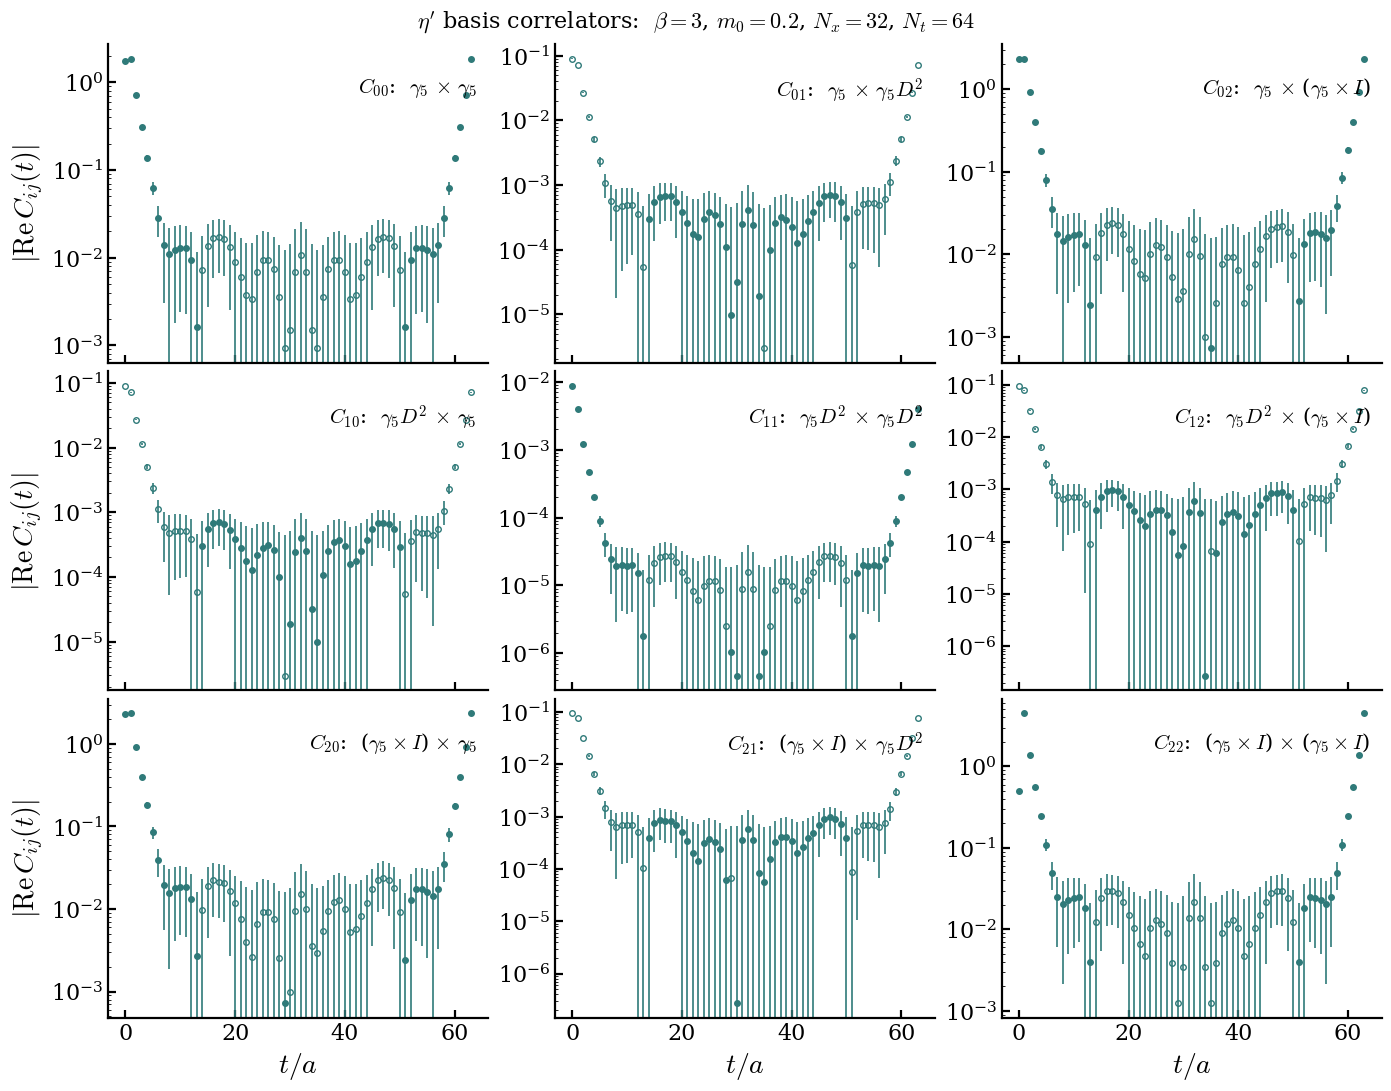

In [19]:
# Raw correlator matrix, exactly as the GEVP sees it: `correls` with no
# reduce is the vacuum-subtracted ensemble mean C_ij(t) plus bootstrap errors.
# Semilogy of |Re C_ij(t)|, FULL n x n grid — hermiticity of the measured
# matrix is NOT assumed (mixed time-reversal operators, e.g. gx alongside g5,
# make C_ij and C_ji genuinely different objects), so compare panels across
# the diagonal to check it where it is expected instead. FILLED
# markers: C_ij > 0; OPEN markers: C_ij < 0 — for a singlet basis the sign
# flips and error-bar blowups mark where the disconnected pieces (or their
# vacuum subtraction) overwhelm the signal, i.e. where the GEVP input is noise.
from schwingerModel import plotting as sp
sp.setStyle()

C, Cerr = correls[0], correls[1]           # (n, n, T), (2, n, n, T)
n, T = C.shape[0], C.shape[-1]
opLabels = [r"$\gamma_5$", r"$\gamma_5 D^2$",r"($\gamma_5 \times I$)"]      # edit to match the basis
if len(opLabels) != n:
    opLabels = [f"op {i}" for i in range(n)]

fig, axes = plt.subplots(n, n, figsize=(4.6 * n, 3.6 * n), sharex=True,
                         layout="constrained", squeeze=False)
ts = np.arange(T)
for i in range(n):
    for j in range(n):
        ax = axes[i][j]
        c = np.real(C[i, j])
        err = np.abs(np.real(Cerr[:, i, j, :]))
        for mask, mfc in ((c > 0, sp.JLab_blue), (c <= 0, "none")):
            if mask.any():
                ax.errorbar(ts[mask], np.abs(c[mask]), yerr=err[:, mask],
                            ls="none", marker="o", ms=4, lw=1.2,
                            color=sp.JLab_blue, mfc=mfc, mec=sp.JLab_blue)
        ax.set_yscale("log")
        ax.text(0.97, 0.90, rf"$C_{{{i}{j}}}$:  {opLabels[i]} $\times$ {opLabels[j]}",
                ha="right", va="top", transform=ax.transAxes, fontsize=15,
                zorder=5, bbox=sp.TEXTBOX)
        if i == n - 1:
            ax.set_xlabel(r"$t/a$")
        if j == 0:
            ax.set_ylabel(r"$|\mathrm{Re}\,C_{ij}(t)|$")

fig.suptitle(rf"$\eta'$ basis correlators:  $\beta = {float(meta.beta):g}$, "
             rf"$m_0 = {float(meta.fMass):g}$, $N_x = {meta.dimx}$, $N_t = {meta.dimt}$",
             fontsize=16)
